In [1]:
from monai.utils import first
from monai.transforms import (
    Compose,
    EnsureChannelFirstD,
    LoadImaged,
    Resized,
    ToTensord,
    Orientationd,
    NormalizeIntensityd,
    CropForegroundd
)

from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.data import Dataset, DataLoader

import torch
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
#defining the path  where the trained model is 
in_dir = r"C:\Users\Dxogu\OneDrive\Desktop\Prostrate Segmentation Project"
model_dir = os.path.join(in_dir, "Models")

In [3]:
train_loss = np.load(os.path.join(model_dir, "loss_train.npy"))
train_metric = np.load(os.path.join(model_dir, "metric_train.npy"))
validation_loss = np.load(os.path.join(model_dir, "loss_validation.npy"))
validation_metric = np.load(os.path.join(model_dir, "metric_validation.npy"))

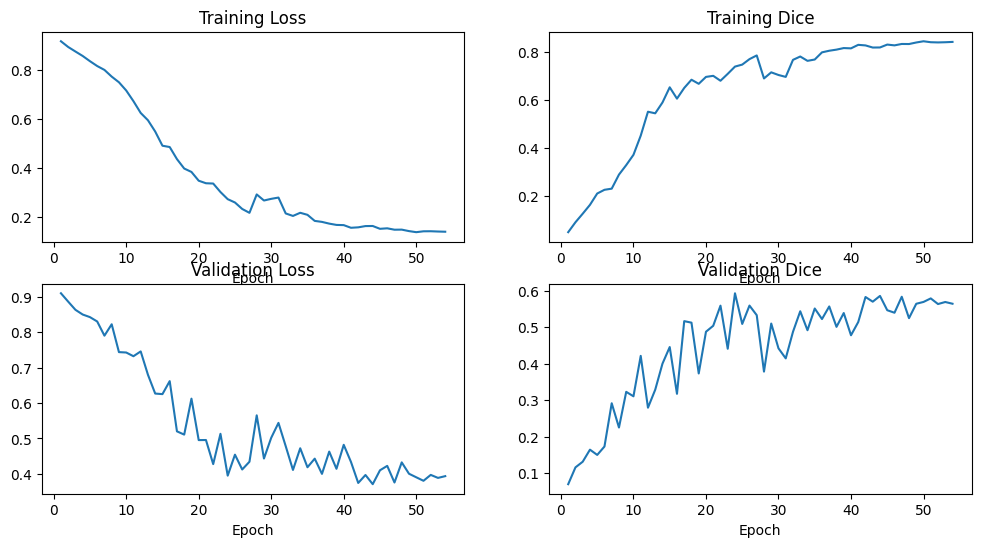

In [4]:
plt.figure("Prostate Segmentation Results", (12, 6))

plt.subplot(2, 2, 1)
plt.title("Training Loss")
x = [i + 1 for i in range(len(train_loss))]
y = train_loss
plt.xlabel("Epoch")
plt.plot(x, y)

plt.subplot(2, 2, 2)
plt.title("Training Dice")
x = [i + 1 for i in range(len(train_metric))]
y = train_metric
plt.xlabel("Epoch")
plt.plot(x, y)

plt.subplot(2, 2, 3)
plt.title("Validation Loss")
x = [i + 1 for i in range(len(validation_loss))]
y = validation_loss
plt.xlabel("Epoch")
plt.plot(x, y)

plt.subplot(2, 2, 4)
plt.title("Validation Dice")
x = [i + 1 for i in range(len(validation_metric))]
y = validation_metric
plt.xlabel("Epoch")
plt.plot(x, y)

plt.show()

In [5]:
test_images_dir = os.path.join(in_dir, "Test", "Images")
test_labels_dir = os.path.join(in_dir, "Test", "Labels")

test_files = []

for case in sorted(os.listdir(test_images_dir)):
    image_path = os.path.join(test_images_dir, case, case + ".nii.gz")
    label_path = os.path.join(test_labels_dir, case, case + "_segmentation.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        test_files.append({"image": image_path, "label": label_path})

print("Number of test cases:", len(test_files))

Number of test cases: 30


In [6]:
test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstD(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS", labels=None),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Resized(keys=["image", "label"], spatial_size=[256, 256, 15], mode=("trilinear", "nearest")),
    ToTensord(keys=["image", "label"])
])

In [7]:
test_ds = Dataset(data=test_files, transform=test_transforms)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

In [8]:
test_patient = first(test_loader)

print("Image shape:", test_patient["image"].shape)
print("Label shape:", test_patient["label"].shape)
print("Unique labels:", torch.unique(test_patient["label"]))

Image shape: torch.Size([1, 1, 256, 256, 15])
Label shape: torch.Size([1, 1, 256, 256, 15])
Unique labels: metatensor([0., 1.])


In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128),
    strides=((2, 2, 1), (2, 2, 1), (2, 2, 1)),
    num_res_units=2,
    norm=Norm.BATCH
).to(device)

print("Device:", device)

Device: cuda:0


In [11]:
#load the best model path
model.load_state_dict(torch.load(os.path.join(model_dir, "best_metric_model.pth"), map_location=device))
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [12]:
with torch.no_grad():

    test_patient = first(test_loader)

    t_volume = test_patient["image"]
    t_segmentation = test_patient["label"]

    test_outputs = model(t_volume.to(device))

    test_prediction = torch.argmax(test_outputs, dim=1, keepdim=True)

print("Prediction shape:", test_prediction.shape)
print("Unique prediction values:", torch.unique(test_prediction))

Prediction shape: torch.Size([1, 1, 256, 256, 15])
Unique prediction values: metatensor([0, 1], device='cuda:0')


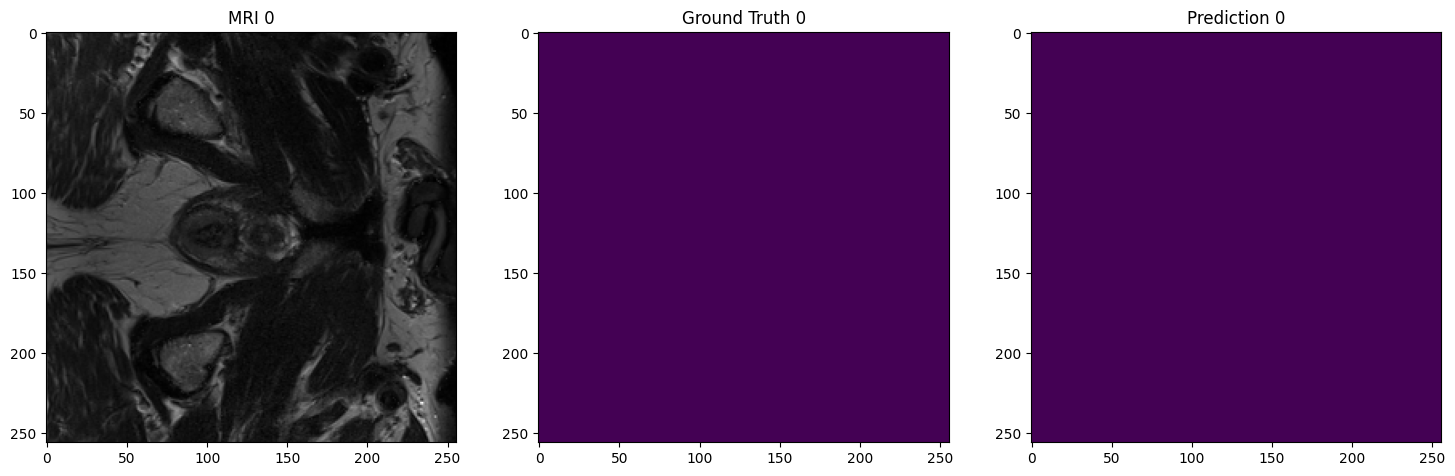

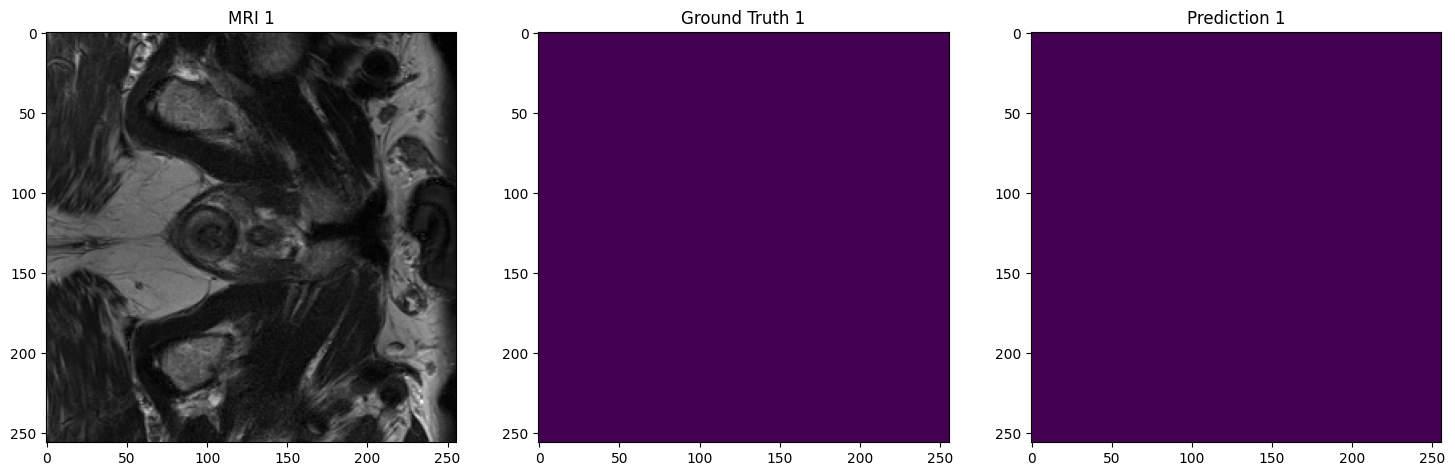

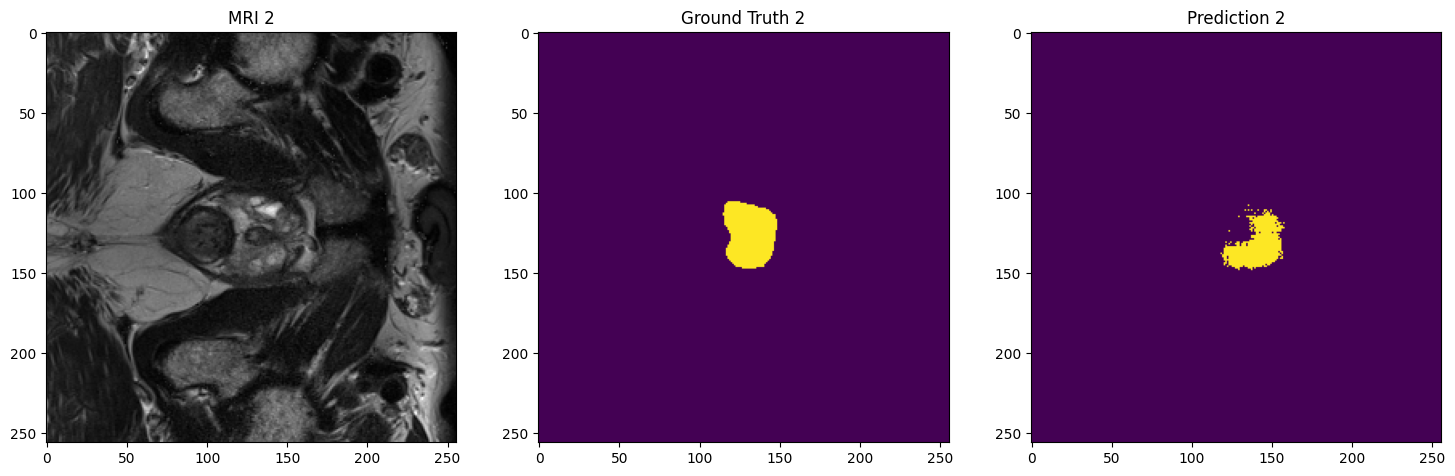

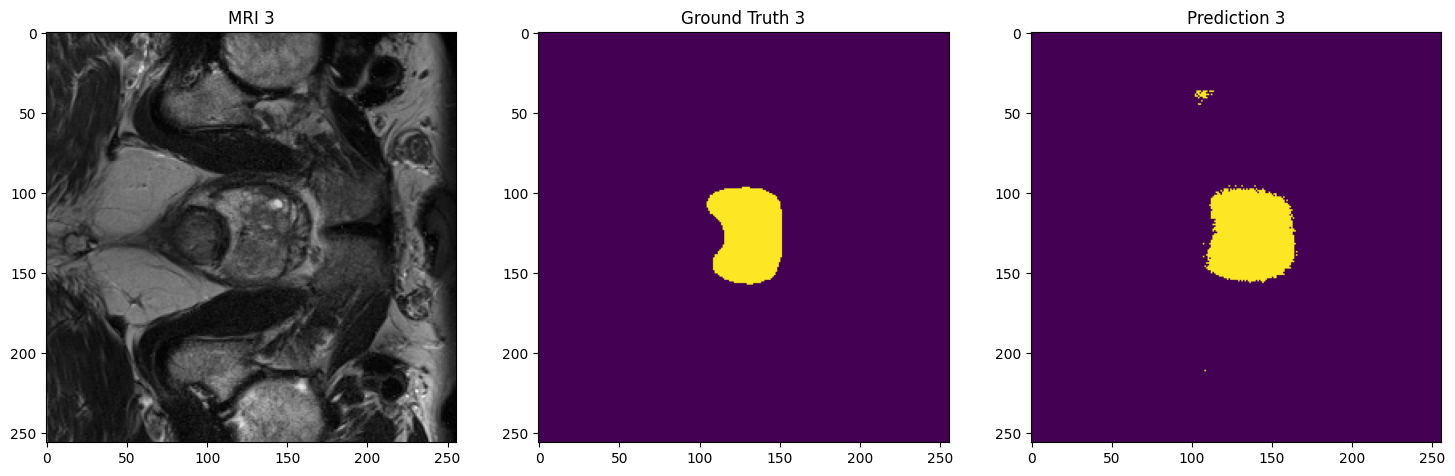

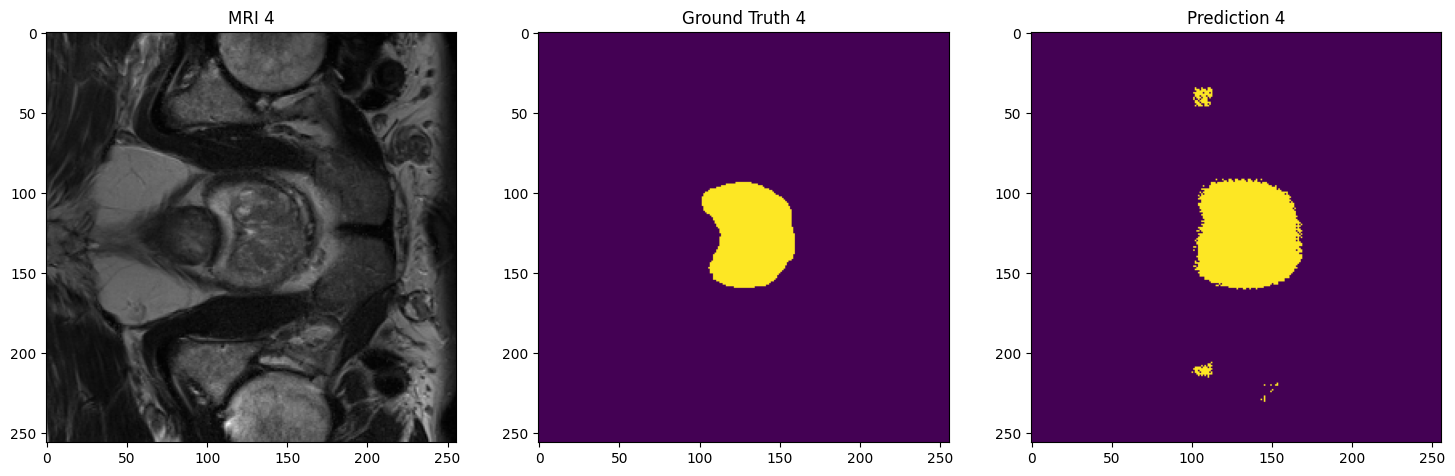

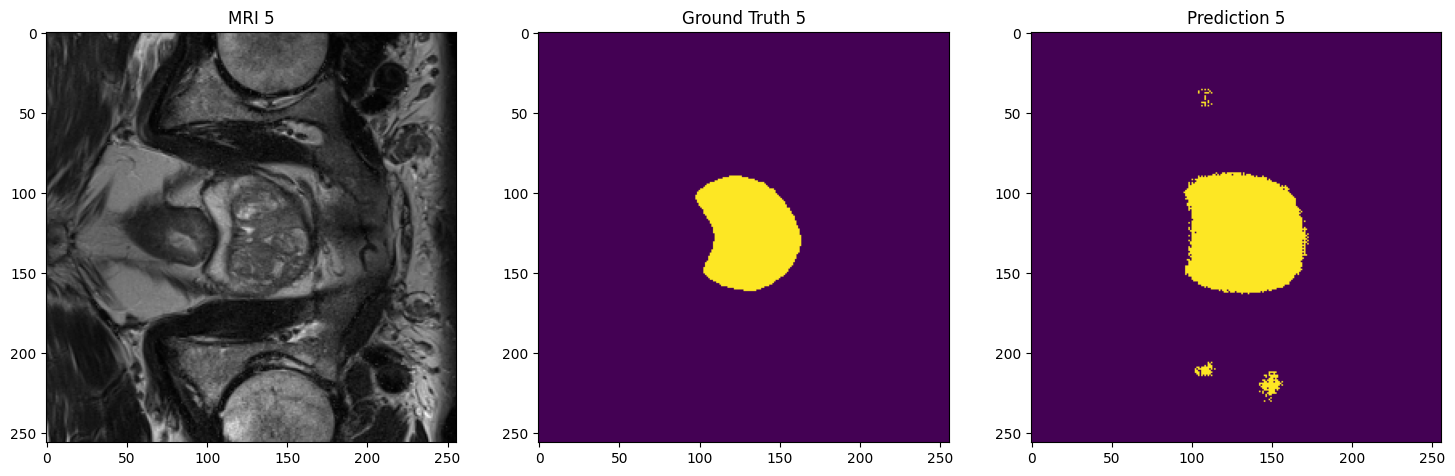

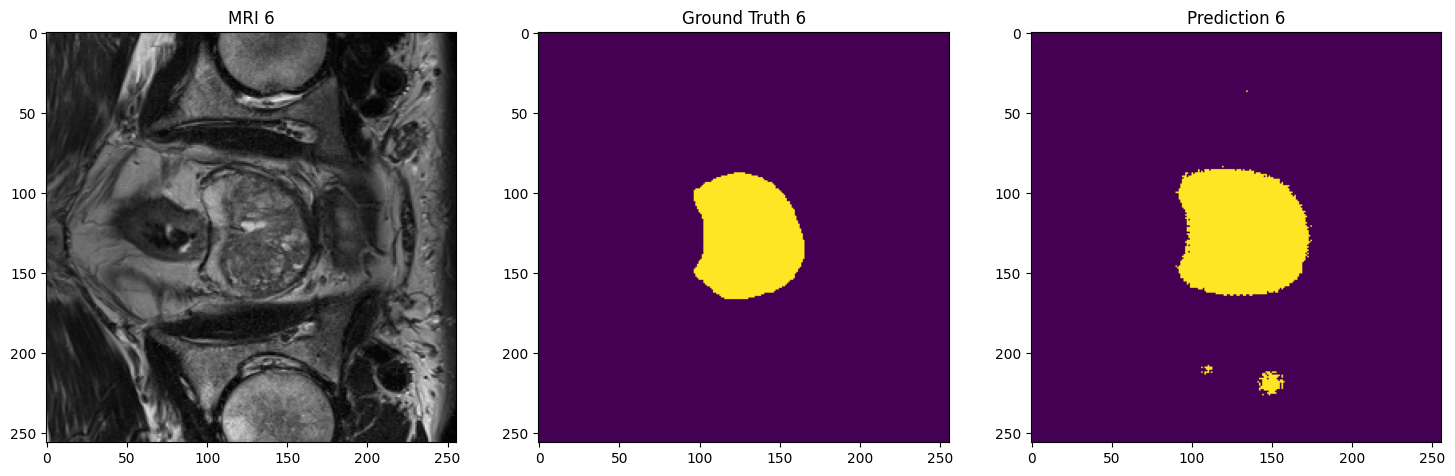

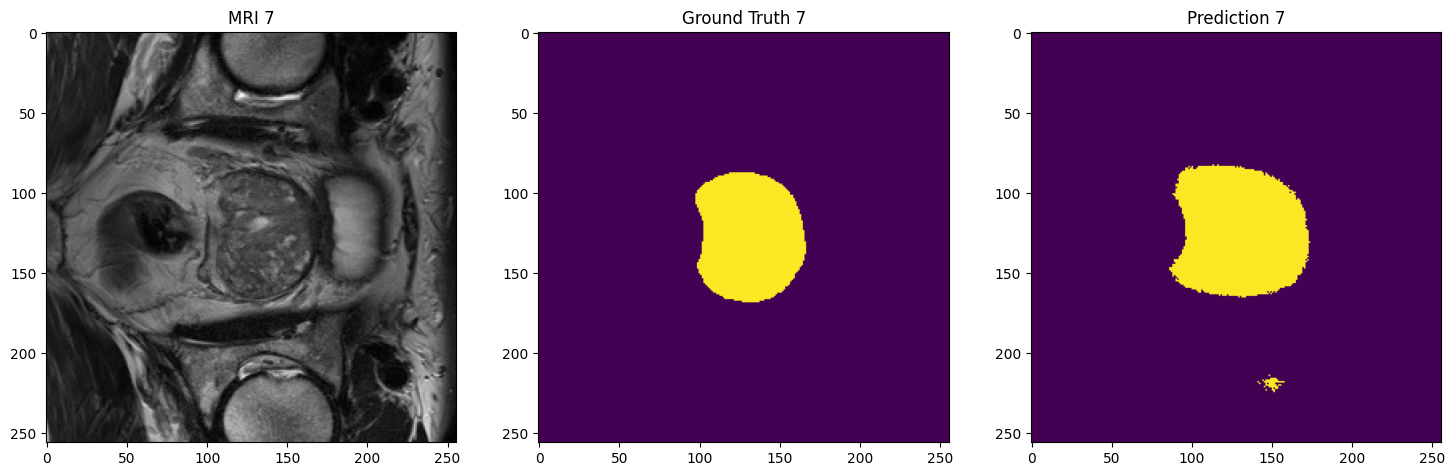

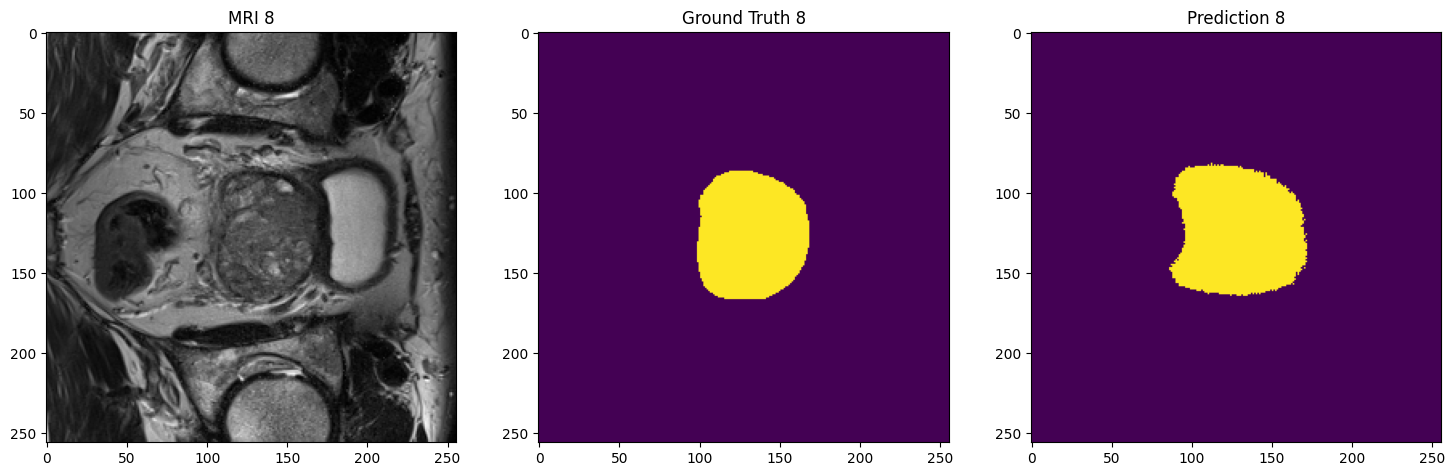

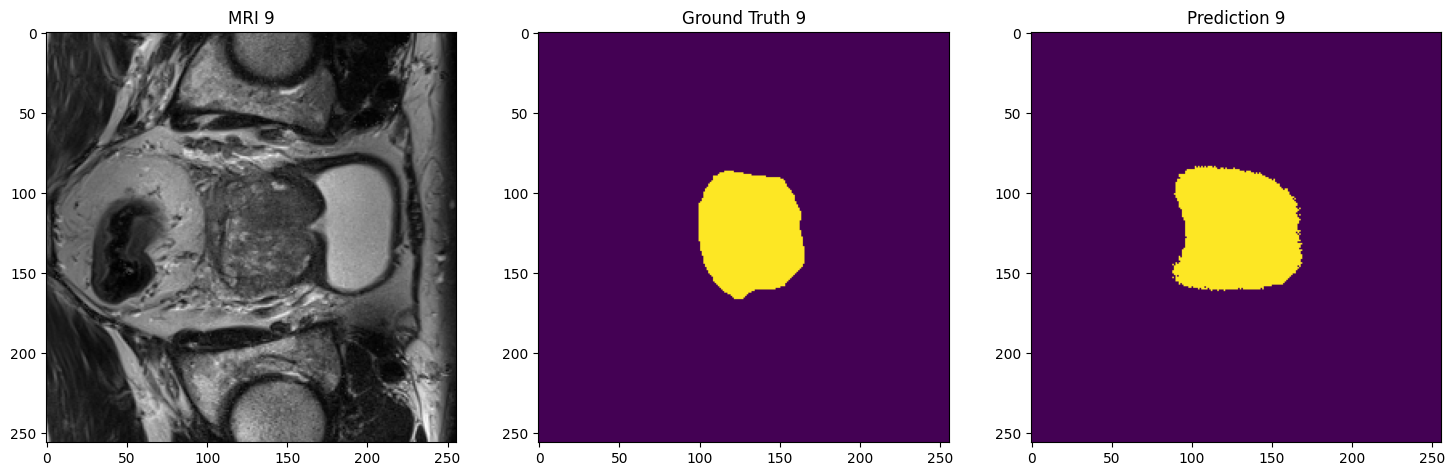

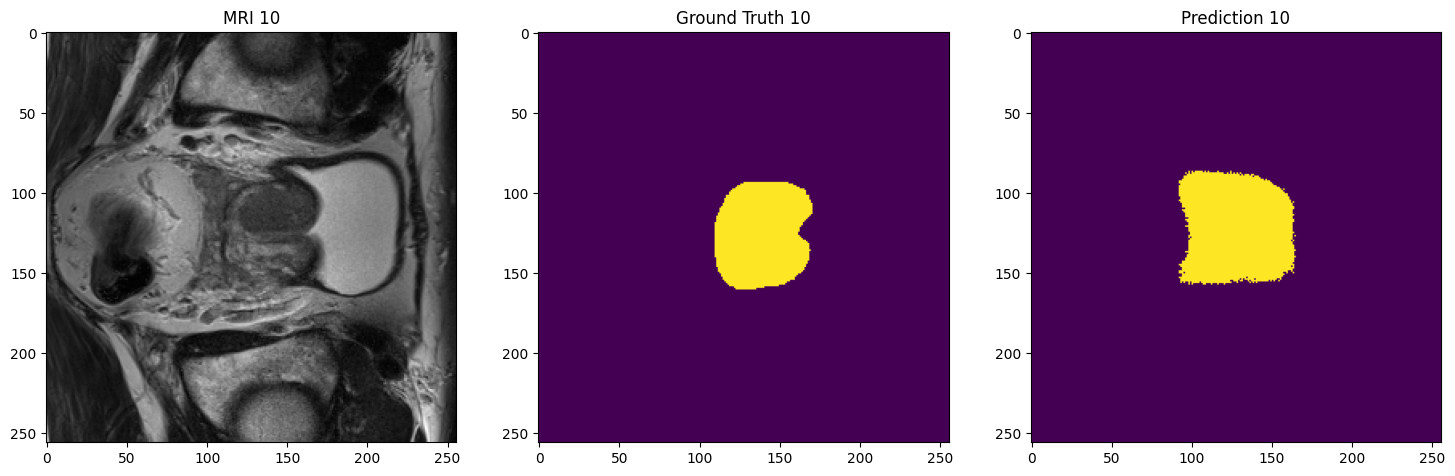

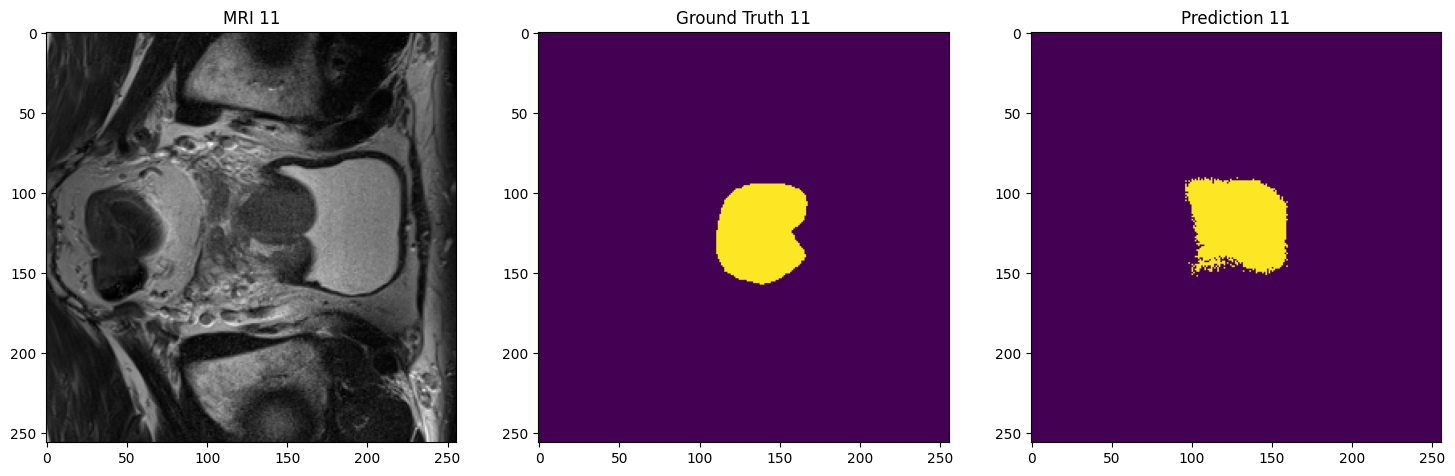

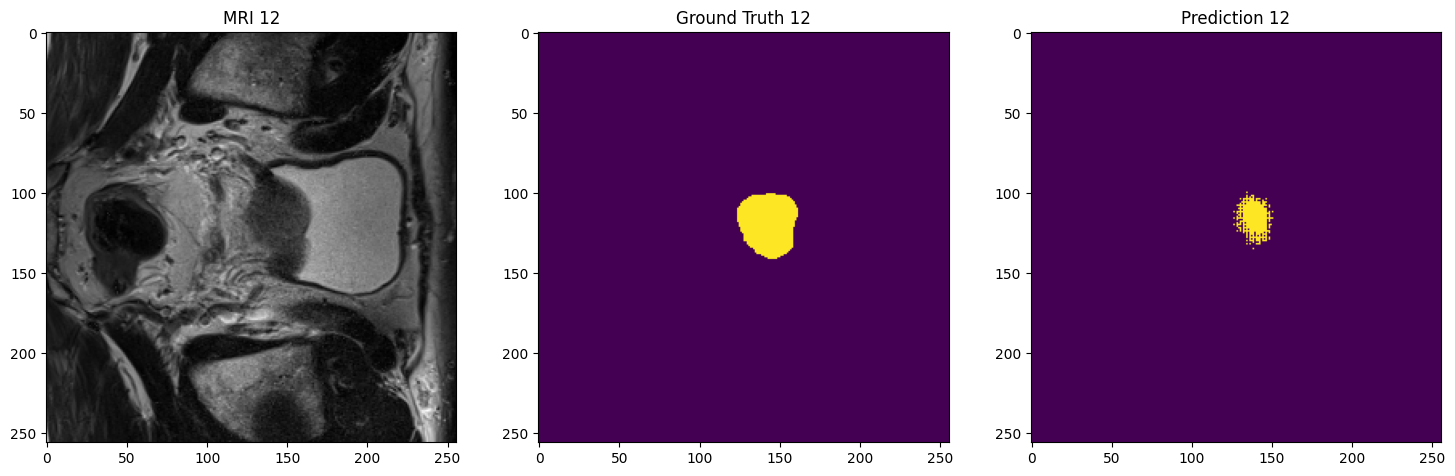

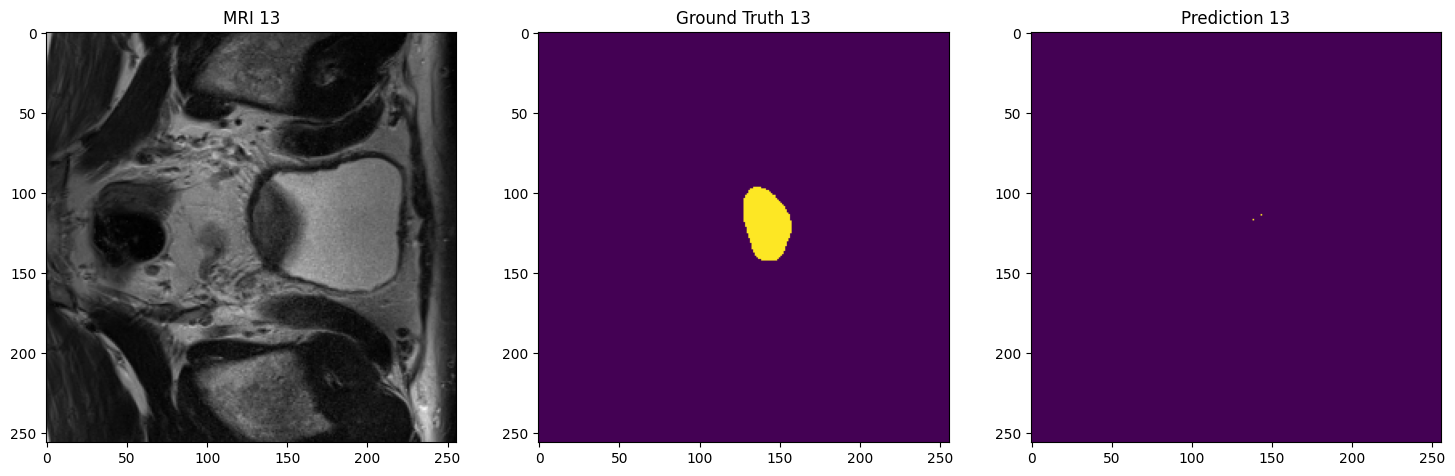

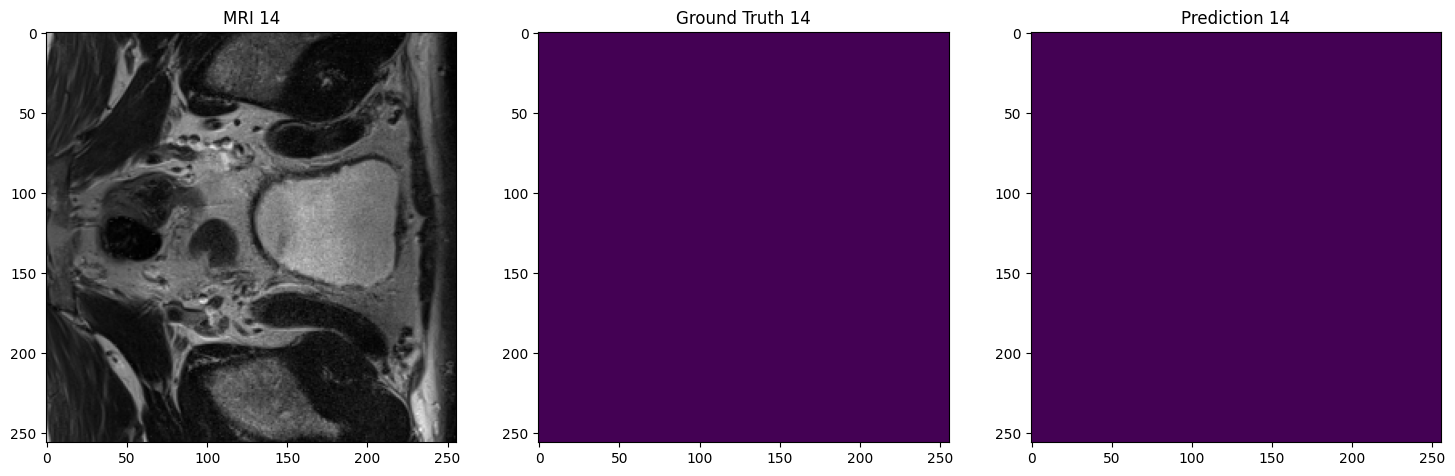

In [13]:
for i in range(15):

    plt.figure("Prostate Prediction", (18, 6))

    plt.subplot(1, 3, 1)
    plt.title(f"MRI {i}")
    plt.imshow(test_patient["image"][0, 0, :, :, i], cmap="gray")

    plt.subplot(1, 3, 2)
    plt.title(f"Ground Truth {i}")
    plt.imshow(test_patient["label"][0, 0, :, :, i])

    plt.subplot(1, 3, 3)
    plt.title(f"Prediction {i}")
    plt.imshow(test_prediction.detach().cpu()[0, 0, :, :, i])

    plt.show()

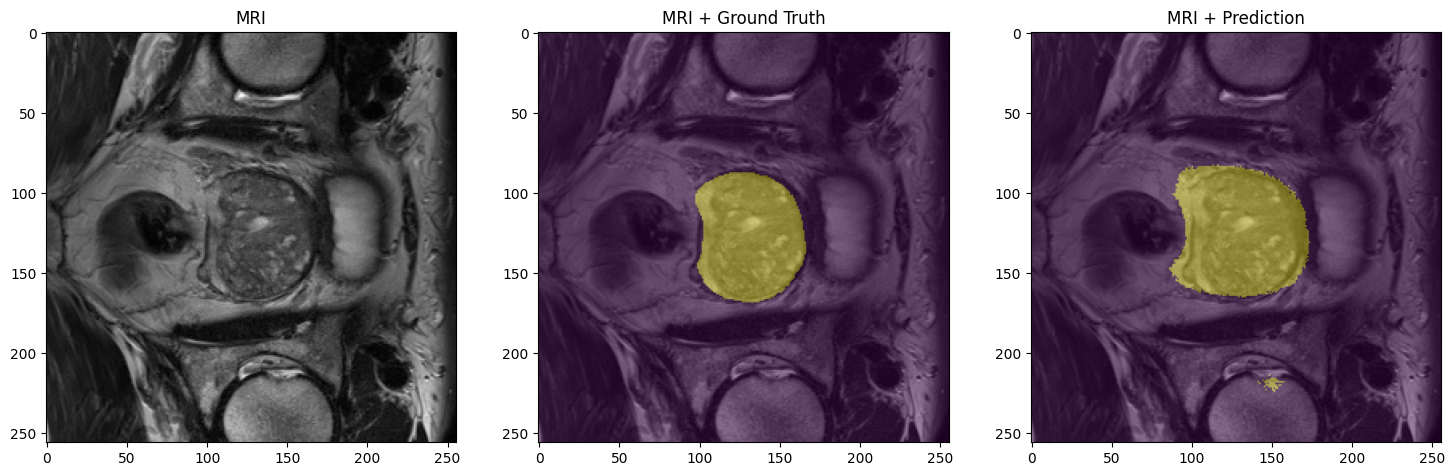

In [25]:
slice_number = 7

plt.figure("Prediction Overlay", (18, 6))

plt.subplot(1, 3, 1)
plt.title("MRI")
plt.imshow(test_patient["image"][0, 0, :, :, slice_number], cmap="gray")

plt.subplot(1, 3, 2)
plt.title("MRI + Ground Truth")
plt.imshow(test_patient["image"][0, 0, :, :, slice_number], cmap="gray")
plt.imshow(test_patient["label"][0, 0, :, :, slice_number], alpha=0.4)

plt.subplot(1, 3, 3)
plt.title("MRI + Prediction")
plt.imshow(test_patient["image"][0, 0, :, :, slice_number], cmap="gray")
plt.imshow(test_prediction.detach().cpu()[0, 0, :, :, slice_number], alpha=0.4)

plt.show()